# Churn Predictor
This notebook aims to study the data gathered from a Bank to predict customer churn.

The game plan is the following:
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing
    + Data Unsampling using SMOTE
    + Principal Component Analysis Of One Hot Encoded Data
3. **Model Selection and Evaluation**
    + Cross Validation
    + Model Evaluation
    + Model Evaluation On Original Data (Before Upsampling)
4. Results

In [ ]:
import pandas as pd

data = pd.read_csv("BankChurners.csv")

# Target
target = "Attrition_Flag"

# Numerical features (EDA-driven)
numerical_features = [
    # Transaction behavior
    "Total_Trans_Ct",
    "Total_Trans_Amt",
    "Avg_Utilization_Ratio",
    "Total_Ct_Chng_Q4_Q1",
    "Total_Amt_Chng_Q4_Q1",
    "Total_Revolving_Bal",

    # Credit_Limit OR Avg_Open_To_Buy
    "Credit_Limit",

    # Engagement & relationship
    "Months_Inactive_12_mon",
    "Contacts_Count_12_mon",
    "Total_Relationship_Count",

    # Demographic / tenure
    "Customer_Age",
    "Months_on_book",
    "Dependent_count",
]

# Categorical features (EDA-selected)
categorical_features = [ # Marital_Status --> weak signaL
    "Gender",
    "Education_Level",
    "Income_Category",
    "Card_Category",
]


# Build modeling dataframe
df = data[numerical_features + categorical_features + [target]].copy()
df.info



<bound method DataFrame.info of        Total_Trans_Ct  Total_Trans_Amt  Avg_Utilization_Ratio  \
0                  42             1144                  0.061   
1                  33             1291                  0.105   
2                  20             1887                  0.000   
3                  20             1171                  0.760   
4                  28              816                  0.000   
...               ...              ...                    ...   
10122             117            15476                  0.462   
10123              69             8764                  0.511   
10124              60            10291                  0.000   
10125              62             8395                  0.000   
10126              61            10294                  0.189   

       Total_Ct_Chng_Q4_Q1  Total_Amt_Chng_Q4_Q1  Total_Revolving_Bal  \
0                    1.625                 1.335                  777   
1                    3.714               

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y # ensures that the class ratio remains the same in 
)


In [5]:
# 2. Encoding (fit on train, transform train and test)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numerical columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns
num_cols = X_train.select_dtypes(exclude=["object", "category"]).columns

# OneHot Encoder
encoder = ColumnTransformer( # EXPLICAR
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]

)

# Fit on training data only
X_train_enc = encoder.fit_transform(X_train)

# Transform test data using learned categories
X_test_enc = encoder.transform(X_test)


In [6]:
# 3. SMOTE (only on training data)
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on the encoded training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_enc, y_train)


In [7]:
# 4. Scaling (fit on training data)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit scaler on SMOTEd training data
X_train_scaled = scaler.fit_transform(X_train_smote)

# Apply the same transformation to test data
X_test_scaled = scaler.fit_transform(X_test_enc)

print("Scaled Train data shape: ", X_train_scaled.shape)
print("Scaled Test data shape: ", X_test_scaled.shape)

Scaled Train data shape:  (13598, 31)
Scaled Test data shape:  (2026, 31)


In [8]:
# 5. PCA (fit on training data, optional)
from sklearn.decomposition import PCA 

# Initialize PCA to retain 95% of the variance
pca = PCA(n_components=0.95, random_state=42)


# Fit PCA on scaled training data
X_train_pca = pca.fit_transform(X_train_scaled)

# Fit PCA on scaled test data
X_test_pca = pca.transform(X_test_scaled)

## Cross-Validation

Cross-validation is a resampling technique used to evaluate machine learning
models when data is limited. The dataset is repeatedly split into training and
validation subsets, allowing the model to be trained and evaluated multiple
times on different portions of the data. This provides a more robust and stable
estimate of model performance than a single train–validation split.

In this project, **stratified cross-validation** is used to ensure that each
fold preserves the original class distribution, which is critical for
imbalanced problems such as customer churn.

#### Why cross-validation?
- Select and compare models **without using the test set**
- Reduce variance in performance estimates
- Provide an implicit validation mechanism without requiring a separate
  validation split

#### Models compared (baseline --> stronger)

The following models are evaluated during cross-validation:

- **Logistic Regression** – baseline model, interpretable and fast
- **Random Forest** – non-linear ensemble model, robust to feature interactions
- **Gradient Boosting** – strong benchmark for structured tabular data
- **XGBoost** – advanced gradient boosting model, widely used in churn
  prediction and industry applications


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # StratifiedKFold defines how the training set is divided during cross-validation.

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boost": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators = 1000,
        learning_rate = 0.01,
        max_depth = 4,
        subsample = 0.8,
        colsample_bytree=0.8,
        reg_lambda =1.0,
        random_state = 42,
        eval_metric = "logloss",
        n_jobs = 1
    )
}

scoring = {
    "roc_auc": "roc_auc",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision"
}

cv_results = {}

y_train_bin = (y_train_smote == "Attrited Customer").astype(int) # in smote target is STRING so we transformed it to int

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train_pca, # PCA-reduced training data
        y_train_bin, # Balanced target
        cv = cv,
        scoring=scoring,
        n_jobs=1
    )
    cv_results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring}

print(pd.DataFrame((cv_results)))

           Logistic Regression  Random Forest  Gradient Boost   XGBoost
roc_auc               0.892179       0.982779        0.950235  0.964982
f1                    0.818156       0.934509        0.880244  0.901318
recall                0.819089       0.932784        0.872626  0.895278
precision             0.817392       0.936264        0.888036  0.907461


### 3.1 Cross-Validation

Model selection is performed using **stratified cross-validation** on the
preprocessed training data. Stratification ensures that each fold preserves the
original class distribution, which is essential in imbalanced classification
problems such as customer churn.

The training set is divided into five folds. In each iteration, the model is
trained on four folds and validated on the remaining one. This procedure is
repeated across all folds to obtain stable and robust performance estimates.

Multiple evaluation metrics are considered during cross-validation, including
ROC-AUC, precision, recall, and F1-score, in order to capture different aspects
of model performance under class imbalance.

### Cross-Validation Results Interpretation

The cross-validation results show clear performance differences across the
evaluated models:

- **Logistic Regression** provides a strong baseline with a ROC-AUC of 0.89 and
  balanced precision, recall, and F1-score. Its performance is solid but limited
  by its linear nature and inability to capture complex feature interactions.

- **Random Forest** achieves the highest overall performance across metrics,
  with a ROC-AUC close to 0.98 and an F1-score above 0.93. This indicates an
  excellent ability to model non-linear relationships and complex interactions
  in the data.

- **Gradient Boosting** performs consistently well, with a ROC-AUC of 0.95 and a
  good balance between precision and recall, but remains slightly below Random
  Forest in all metrics.

- **XGBoost** delivers very strong performance, with a ROC-AUC of 0.96 and an
  F1-score above 0.90. Compared to Gradient Boosting, XGBoost shows improved
  recall and precision, confirming its effectiveness for churn prediction on
  tabular data.

Overall, **Random Forest** emerges as the top-performing model during
cross-validation, while **XGBoost** represents a close and competitive
alternative. Both models are therefore strong candidates for final evaluation
on the test set.

In [10]:
# 3.2  Model Evaluation

# Train final model on full SMOTEd training data
final_model = RandomForestClassifier(random_state=42)

final_model.fit(X_train_pca, y_train_smote) # Why PCA on set

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### SMOTE vs PCA: Different Roles in the Pipeline

SMOTE and PCA address different aspects of the data and therefore operate on
different dimensions of the dataset.

**SMOTE**
- Modifies the **number of samples**
- Operates on both features and target (`X_train` and `y_train`)
- Output: `X_train_smote`, `y_train_smote`

**PCA**
- Modifies the **number of features**
- Operates only on the feature matrix (`X`)
- Output: `X_train_pca`

As a result, these techniques are applied sequentially and are not
interchangeable.

PCA is applied to the feature matrix in order to reduce dimensionality, while
SMOTE is applied to the training data to balance class distribution by
generating synthetic samples of the minority class. SMOTE operates jointly on
features and labels, producing a balanced feature matrix and corresponding
target vector.

As a result, the final model is trained using PCA-transformed features
(`X_train_pca`) and SMOTEd labels (`y_train_smote`).



In [11]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Predictions
y_test_pred = final_model.predict(X_test_pca)
y_test_proba = final_model.predict_proba(X_test_pca)[:, 1] #???
    # predict_proba() gives you the estimated probability of each class
    # y_test_pred_xgb[:, 1] = probabilidad de la clase positiva (churn / Attrited)


# Metrics
print("Classification Report (Test Set): \n", classification_report(y_test, y_test_pred), "\n")
print("ROC-AUC (Test Set): " , roc_auc_score(y_test, y_test_proba))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_test_pred))


Classification Report (Test Set): 
                    precision    recall  f1-score   support

Attrited Customer       0.44      0.84      0.57       325
Existing Customer       0.96      0.79      0.87      1701

         accuracy                           0.80      2026
        macro avg       0.70      0.82      0.72      2026
     weighted avg       0.88      0.80      0.82      2026
 

ROC-AUC (Test Set):  0.8951612173834396
Confusion Matrix: 
 [[ 274   51]
 [ 355 1346]]


### Test Set Evaluation Interpretation

The model achieves a ROC-AUC of 0.895 on the test set, indicating strong
discriminative ability between attrited and existing customers.

For the attrited customer class, recall is high (0.84), meaning that most
churners are correctly identified. Precision is lower (0.44), reflecting a
higher number of false positives. This trade-off is expected when training on
SMOTEd data and is often acceptable in churn prediction, where missing churners
is typically more costly than incorrectly flagging loyal customers.

Overall, the model demonstrates robust performance with a clear emphasis on
churn detection, making it suitable for downstream business decision-making.

In [12]:
#  3.3  Model Evaluation On Original Data (Before Upsampling)
# How does the model behave under real-world class imbalance?

# Transform original (non-SMOTEd) training data
X_train_orig_scaled = scaler.transform(X_train_enc)
X_train_orig_pca = pca.transform(X_train_orig_scaled)

#
# True labels (binary)
y_train_orig_bin = (y_train == "Attrited Customer").astype(int)

# Predictions from RF (strings -> binary)
y_train_orig_pred = final_model.predict(X_train_orig_pca)
y_train_orig_pred_bin = (y_train_orig_pred == "Attrited Customer").astype(int)

# Probabilities (take probability of the positive class)
pos_index = list(final_model.classes_).index("Attrited Customer")
y_train_orig_proba = final_model.predict_proba(X_train_orig_pca)[:, pos_index]

print("Random Forest — Evaluation on Original (Imbalanced) Training Data")
print(classification_report(y_train_orig_bin, y_train_orig_pred_bin))
print("ROC-AUC:", roc_auc_score(y_train_orig_bin, y_train_orig_proba))
print("Confusion Matrix:\n", confusion_matrix(y_train_orig_bin, y_train_orig_pred_bin))

Random Forest — Evaluation on Original (Imbalanced) Training Data
              precision    recall  f1-score   support

           0       0.99      0.83      0.91      6799
           1       0.53      0.97      0.68      1302

    accuracy                           0.85      8101
   macro avg       0.76      0.90      0.79      8101
weighted avg       0.92      0.85      0.87      8101

ROC-AUC: 0.9726957904038025
Confusion Matrix:
 [[5661 1138]
 [  41 1261]]


/Users/palomaperezdemadrid/Desktop/Data Scientist/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


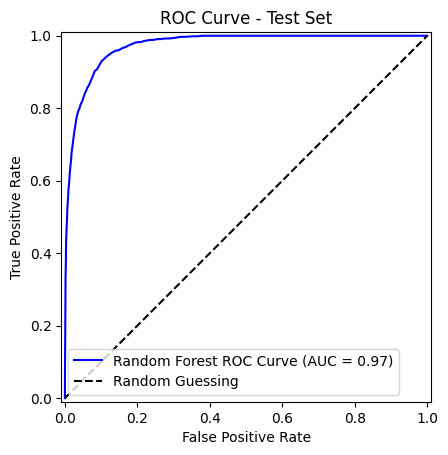

In [19]:
# Create a ROC–AUC curve plot
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_train_orig_bin,
    y_train_orig_proba,
    name="Random Forest ROC Curve",
    color="blue"
)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.title("ROC Curve - Test Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

The ROC curve on the test set shows an excellent discriminative performance, achieving an AUC of 0.97.
This indicates that the Random Forest model is highly effective at distinguishing between attrited and existing customers, even under class imbalance conditions.

### Interpretation: Evaluation on Original (Imbalanced) Training Data

When evaluated on the original, imbalanced training data, the Random Forest
model maintains strong overall performance while exhibiting a clear and
interpretable trade-off between precision and recall for the churn class.

The model achieves a **ROC-AUC of 0.97**, indicating excellent discriminative
ability even under real-world class proportions. This suggests that the model
learned a robust separation between attrited and existing customers during
training on the SMOTEd dataset.

For the churn class (Attrited Customer):
- **Recall = 0.97**, meaning that the model correctly identifies nearly all
  churners.
- **Precision = 0.53**, indicating that some non-churn customers are
  incorrectly flagged as potential churners.

This behavior reflects a deliberate bias introduced by training on balanced
data: the model prioritizes capturing churners at the expense of generating
additional false positives. From a business perspective, this trade-off is
often acceptable in churn prediction, where missing a churner is typically
more costly than contacting a loyal customer unnecessarily.

Overall, this evaluation demonstrates that the Random Forest model generalizes
well to realistic, imbalanced data distributions and remains suitable for
deployment, particularly in scenarios where recall for churn detection is a
priority. Potential next steps include threshold tuning to better balance
precision and recall based on business objectives.
